In [1]:
from nvidia.dali.pipeline import experimental, pipeline_def
from nvidia.dali.types import DALIDataType
from nvidia.dali import fn
from nvidia.dali import types
from nvidia.dali import tensors

from nvidia.dali.data_node import DataNode as _DataNode

from functools import wraps

import numpy as np

# dynamic and static magnitude
# shapes
# negation of the range
# big decorator
# range and the param dtype

In [2]:
data_path = "/home/ktokarski/DALI_extra/db/single/jpeg"

import os
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def display_imgs(outputs, columns=2, captions=None, cpu=True):
    rows = (len(outputs) + columns - 1) // columns
    fig = plt.figure()
    fig.set_size_inches(16, 6 * rows)
    gs = gridspec.GridSpec(rows, columns)
    row = 0
    col = 0
    for i in range(len(outputs)):
        plt.subplot(gs[i])
        plt.axis("off")
        if captions is not None:
            plt.title(captions[i])
        if hasattr(outputs, 'at'):
            out = outputs.at(i) if cpu else outputs.as_cpu().at(i)
        else:
            out = outputs[i]
        if len(out.shape) == 2 or (len(out.shape) == 3 and out.shape[-1] == 1):
            plt.imshow(out, cmap='gray')
        else:
            plt.imshow(out)

In [3]:
def as_param_(mag):
    return np.array(mag)

def as_param_data_node_(magnitudes, magnitude_idx, as_param, param_dev):
    params = np.array([as_param(magnitude) for magnitude in magnitudes])
    params = types.Constant(params, device=param_dev)
    return params[magnitude_idx]
    
def augmentation(lo, hi, num_magnitudes=11, as_param=None, as_param_data_node=None, param_dev="cpu"):
    magnitudes = np.linspace(lo, hi, num_magnitudes, dtype=np.float32)
    if as_param is None:
        as_param = as_param_
    if as_param_data_node is None:
        as_param_data_node = as_param_data_node_
    def decorator(function):
        @wraps(function)
        def wrapper(samples, magnitude_idx):
            if isinstance(magnitude_idx, _DataNode):
                param = as_param_data_node(magnitudes, magnitude_idx, as_param, param_dev)
            else:
                magnitude = magnitudes[magnitude_idx]
                param = as_param(magnitude)
            return function(samples, param)  
        return wrapper
    return decorator

In [4]:
def warp_x_param(magnitude):
    return [magnitude, 0]

@augmentation(0, 0.3, as_param=warp_x_param)
def shear_x(samples, parameter):
    mt = fn.transforms.shear(shear=parameter)
    return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

def warp_y_param(magnitude):
    return [0, magnitude]

@augmentation(0, 0.3, as_param=warp_y_param)
def shear_y(samples, parameter):
    mt = fn.transforms.shear(shear=parameter)
    return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

@augmentation(0, 250, as_param=warp_x_param)
def translate_x(samples, parameter):
    mt = fn.transforms.translation(offset=parameter)
    return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

@augmentation(0, 250, as_param=warp_y_param)
def translate_y(samples, parameter, as_param=warp_y_param):
    mt = fn.transforms.translation(offset=parameter)
    return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

@augmentation(0, 30)
def rotate(samples, parameter):
    return fn.rotate(samples, angle=parameter, fill_value=0)

@augmentation(0.1, 1.9)
def brightness(samples, parameter):
    return fn.brightness(samples, brightness=parameter)

@augmentation(0.1, 1.9)
def contrast(samples, parameter):
    return fn.contrast(samples, contrast=parameter)

@augmentation(0.1, 1.9)
def color(samples, parameter):
    return fn.saturation(samples, saturation=parameter)

def posterize_param(magnitude):
    nbits = np.round(magnitude).astype(np.int32)
    return np.array(255 ^ (2 ** (8 - nbits) - 1), dtype=np.uint8)

@augmentation(0, 4, as_param=posterize_param, param_dev="gpu")
def posterize(samples, mask):
    return samples & mask

@augmentation(0, 110, param_dev="gpu")
def solarize(samples, threshold):
    samples_inv = 255 - samples
    mask_left = samples < threshold
    mask_right = 1 - mask_left
    return fn.cast(mask_left * samples + mask_right * samples_inv, dtype=types.UINT8)

@augmentation(0, 256, param_dev="gpu")
def solarize_add(samples, shift):
    samples_shifted = fn.cast_like(samples + shift, samples)
    mask_left = samples < 128
    mask_right = 1 - mask_left
    return fn.cast_like(mask_left * samples_shifted + mask_right * samples, samples)

def sharpness_param(magnitude):
    blur = np.array([
        [1, 1, 1],
        [1, 5, 1],
        [1, 1, 1]],
        dtype=np.float32) / 13
    ident = np.array([
        [0, 0, 0],
        [0, 1, 0],
        [0, 0, 0]],
        dtype=np.float32)
    return (1 - magnitude) * blur + magnitude * ident

@augmentation(0.1, 1.9, as_param=sharpness_param, param_dev="gpu")
def sharpness(samples, kernel):
    return fn.experimental.filter(samples, kernel)

@augmentation(0, 0)
def invert(samples, _):
    return fn.cast_like(255 - samples, samples)

@augmentation(0, 0)
def equalize(samples, _):
    return fn.experimental.equalize(samples)

@augmentation(0, 0)
def autocontrast(samples, _):
    lo, hi = fn.reductions.min(samples, axes=[-3, -2]), fn.reductions.max(samples, axes=[-3, -2])
    lo = fn.expand_dims(lo, axes=[0, 1])
    hi = fn.expand_dims(hi, axes=[0, 1])
    return fn.cast_like((samples - lo) * (255 / (hi - lo)), samples)

In [5]:
def get_operations(num_total_ops, N):
    rng = np.random.default_rng(12345)
    def inner(sample_info):
        return rng.choice(range(num_total_ops), N)
    return inner

def split_level(op_range_lo, op_range_hi, ops, samples, M, level_op_idxs):
    assert op_range_lo <= op_range_hi
    if op_range_lo == op_range_hi:
        return ops[op_range_lo](samples, M)
    mid = (op_range_lo + op_range_hi) // 2
    if level_op_idxs <= mid:
        return split_level(op_range_lo, mid, ops, samples, M, level_op_idxs)
    else:
        return split_level(mid + 1, op_range_hi, ops, samples, M, level_op_idxs)

def trivial_augment(ops, samples, num_bins=11):  # todo should be 31
    num_total_ops = len(ops)
    op_idxs = fn.external_source(source=get_operations(num_total_ops, 1), batch=False)
    magnitudes = fn.random.uniform(range=[0, num_bins - 1], dtype=types.INT32)
    samples = split_level(0, num_total_ops - 1, ops, samples, magnitudes, op_idxs[0])
    return samples

In [6]:
trivial_aug_ops = [shear_x, shear_y, translate_x, translate_y, rotate, brightness, contrast, color, posterize, solarize, solarize_add, sharpness, invert, equalize, autocontrast]

@experimental.pipeline_def(enable_conditionals=True, seed=42)
def pipeline():
    images, _ = fn.readers.file(name="Reader", file_root=data_path, random_shuffle=True, seed=42)
    shapes = fn.peek_image_shape(images)
    images = fn.decoders.image(images, device="mixed")
    images = fn.resize(images, resize_x=400, resize_y=400)
    return trivial_augment(trivial_aug_ops, images), shapes

In [8]:
p = pipeline(batch_size=12, device_id=0, num_threads=4)

In [9]:
p.build()
p.save_graph_to_dot_file("hmhmhm.dot")

In [10]:
out, shapes = p.run()

In [11]:
out = [np.array(s) for s in out.as_cpu()]

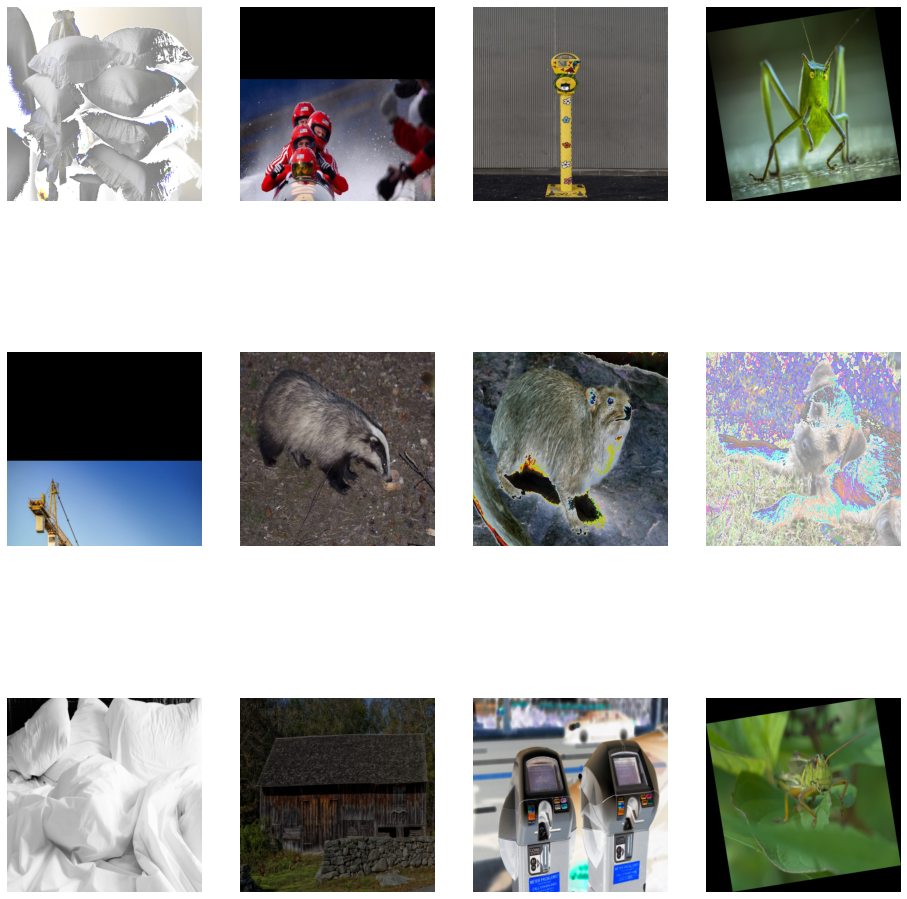

In [12]:
display_imgs(out, columns=4)